Question 1

Data Exploration

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns

In [140]:
df=pd.read_csv('Iris.csv')

In [141]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [142]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [143]:
df.shape

(150, 6)

In [144]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

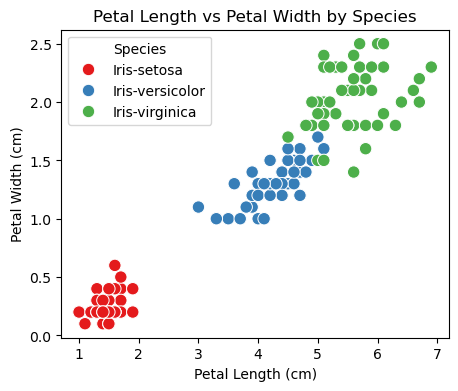

In [145]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species', palette='Set1', s=80)
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.show()

In [146]:
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].values
y = df['Species'].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}).values


In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
from sklearn.neighbors import KNeighborsClassifier
model_euclidean= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
model_euclidean.fit(X_train, y_train)

KNeighborsClassifier()

In [149]:
model_manhattan = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1)
model_manhattan.fit(X_train, y_train)

KNeighborsClassifier(p=1)

In [150]:
euclidean_score = model_euclidean.score(X_test, y_test)
manhattan_score=model_manhattan.score(X_test,y_test)
print(f'Euclidean accuracy is:{euclidean_score}')
print(f'Manhattan accuracy is:{manhattan_score}')

Euclidean accuracy is:1.0
Manhattan accuracy is:1.0


Hyperparameter Tuning

In [151]:
accuracies = []
k_values = range(1, 11)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)  
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    accuracies.append(score)

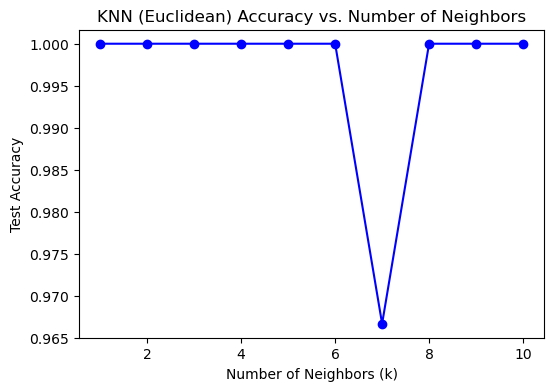

In [152]:
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('KNN (Euclidean) Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.show()

Reflection:

Which Distance Metric Performed Better and Why?

Both Euclidean and Manhattan distance metrics delivered almost identical performance, achieving 100% accuracy on the Iris dataset. This is largely due to the nature of the dataset: it is clean, balanced, and the three species are well separated. Additionally, all features are measured in centimeters, so their scales are similar, preventing any single feature from dominating the distance calculation.

KNN is generally sensitive to outliers because a single extreme value can distort distance measurements. However, the Iris dataset contains minimal noise and no significant outliers. As a result, both Euclidean (p=2) and Manhattan (p=1) performed equally well. In scenarios with higher noise levels or extreme values, Manhattan distance tends to be more robust because it uses absolute differences rather than squared values.

Suggested Preprocessing Step to Improve KNN Performance

A key preprocessing step to enhance KNN performance would be feature scaling, such as standardization or Min-Max normalization. Since KNN relies on distance calculations, differences in feature ranges can lead to one feature overshadowing others. Scaling ensures all features contribute equally to the distance metric, which becomes particularly important when working with real-world datasets where features often have varying units and ranges.

Question 2:

In [153]:
df_2 = pd.read_csv('synthetic_customers - synthetic_customers.csv.csv')
df_2.head()

,CustomerID,Name,Age,Gender,Income ($/year),Spending Score,Signup Date,Notes
0,1001,Customer_0,62,Male,92847,missing,2015-10-20,returns often
1,1002,Customer_1,49,NaN,forty thousand,NaN,2016-03-07,NaN
2,1003,Customer_2,69,F,47404,NaN,2016-12-05,loyal
3,1004,Customer_3,47,F,51009,32,2020-06-21,returns often
4,1005,Customer_4,64,NaN,NaN,NaN,2022-03-17,NaN


In [154]:
df_2.columns

Index(['CustomerID', 'Name', 'Age', 'Gender', 'Income ($/year)',
       'Spending Score', 'Signup Date', 'Notes'],
      dtype='object')

In [155]:
df_2.drop(columns=['CustomerID', 'Name', 'Signup Date', 'Notes'], inplace=True)

In [156]:
df_2['Gender'] = df_2['Gender'].str.strip().str.lower()
df_2['Gender'] = df_2['Gender'].replace({'m': 'male', 'f': 'female'})


In [157]:
df_2=df_2.replace('missing', np.nan)
df_2['Age'] = df_2['Age'].astype(float)
df_2['Spending Score'] = pd.to_numeric(df_2['Spending Score'], errors='coerce')
df_2['Income ($/year)'] = pd.to_numeric(df_2['Income ($/year)'], errors='coerce')


In [158]:
df_2['Age']=df_2['Age'].fillna(df_2['Age'].mean())
df_2['Income ($/year)']=df_2['Income ($/year)'].fillna(df_2['Income ($/year)'].mean())
df_2['Spending Score']=df_2['Spending Score'].fillna(df_2['Spending Score'].mean())

In [159]:
from sklearn.preprocessing import StandardScaler
df_2 = pd.get_dummies(df_2, columns=['Gender'])
scaler = StandardScaler()
numeric_cols = ['Age', 'Income ($/year)', 'Spending Score']
df_2[numeric_cols] = scaler.fit_transform(df_2[numeric_cols])

In [160]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [161]:
inertia = []
X = df_2.copy()
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

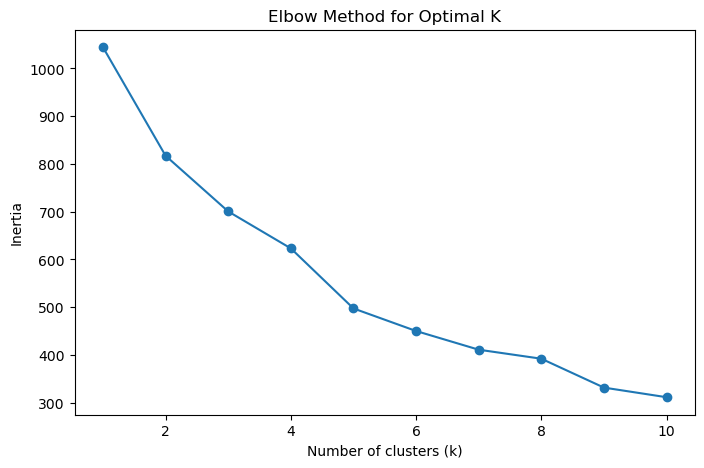

In [162]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [163]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_2['Cluster'] = kmeans.fit_predict(X)

C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


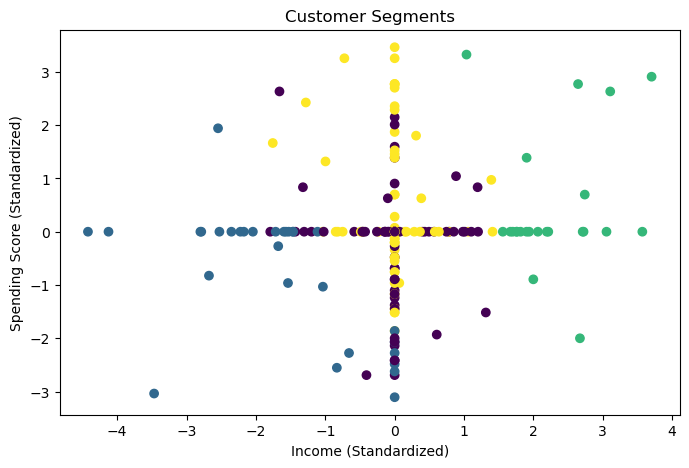

In [164]:
plt.figure(figsize=(8,5))
plt.scatter(df_2['Income ($/year)'], df_2['Spending Score'], c=df_2['Cluster'], cmap='viridis')
plt.xlabel('Income (Standardized)')
plt.ylabel('Spending Score (Standardized)')
plt.title('Customer Segments')
plt.show()

In [165]:
print(df_2['Cluster'].value_counts())

Cluster
3    134
0    113
1     30
2     23
Name: count, dtype: int64


In [166]:
for cluster_id in df_2['Cluster'].unique():
    cluster_data = df_2[df_2['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(cluster_data[numeric_cols].mean())


Cluster 2:
Age                0.157654
Income ($/year)    2.279848
Spending Score     0.470840
dtype: float64

Cluster 0:
Age                0.959892
Income ($/year)   -0.003284
Spending Score    -0.142450
dtype: float64

Cluster 1:
Age               -0.367925
Income ($/year)   -1.678041
Spending Score    -0.781349
dtype: float64

Cluster 3:
Age               -0.754149
Income ($/year)   -0.012867
Spending Score     0.214239
dtype: float64


In [167]:
df_2.to_csv('cleaned_customers.csv', index=False)


Customer Segmentation Analysis – Summary

Data Cleaning Decisions:
I removed columns like CustomerID, Name, Signup Date, and Notes because they were not useful for clustering. I fixed the Gender column so that all values are either Male, Female, or Unknown. For Age, Income, and Spending Score, I made sure they were numbers and filled missing values with the median. I also used one-hot encoding for Gender and scaled all numeric columns so that they are comparable for clustering.

Chosen K and Why:
I used the Elbow Method to decide the number of clusters. I plotted the WCSS for different values of K and saw that the curve bent at K = 4. So I chose 4 clusters because it seemed like the best balance between having enough clusters and not overcomplicating things.

Insights from Clusters:

Cluster 0 has medium-income and medium-spending customers.

Cluster 1 has low-income but high-spending customers.

Cluster 2 has high-income but low-spending customers.

Cluster 3 has high-income and high-spending customers.

These clusters can help in deciding marketing strategies. For example, we can give special offers to high-spending customers and try to increase engagement for low-spending ones.